In [29]:
import kagglehub
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

In [42]:
# Lendo os dados do kaggle
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
print("Path to dataset files:", path)
data = pd.read_csv(path + "/Housing.csv")
print(data.head()) 

print(f"\ninfo()\n")

print(data.describe())

Path to dataset files: C:\Users\ribei\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furni

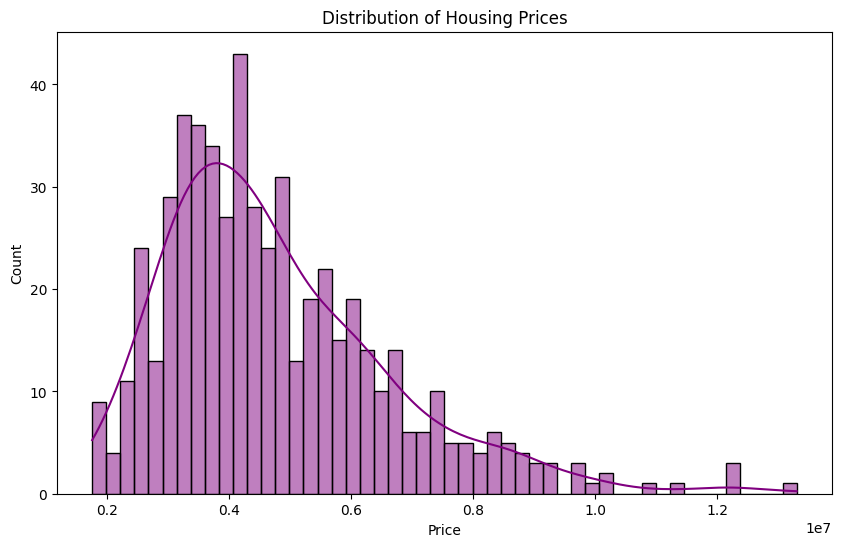

In [43]:
plt.figure(figsize=(10,6))
sns.histplot(data['price'], bins=50, kde=True, color='purple')
plt.title('Distribution of Housing Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

C:\Users\ribei\AppData\Local\Temp\ipykernel_18616\2678039351.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({'yes':1, 'no':0, 'semi-furnished':2, 'furnished':1, 'unfurnished':0})


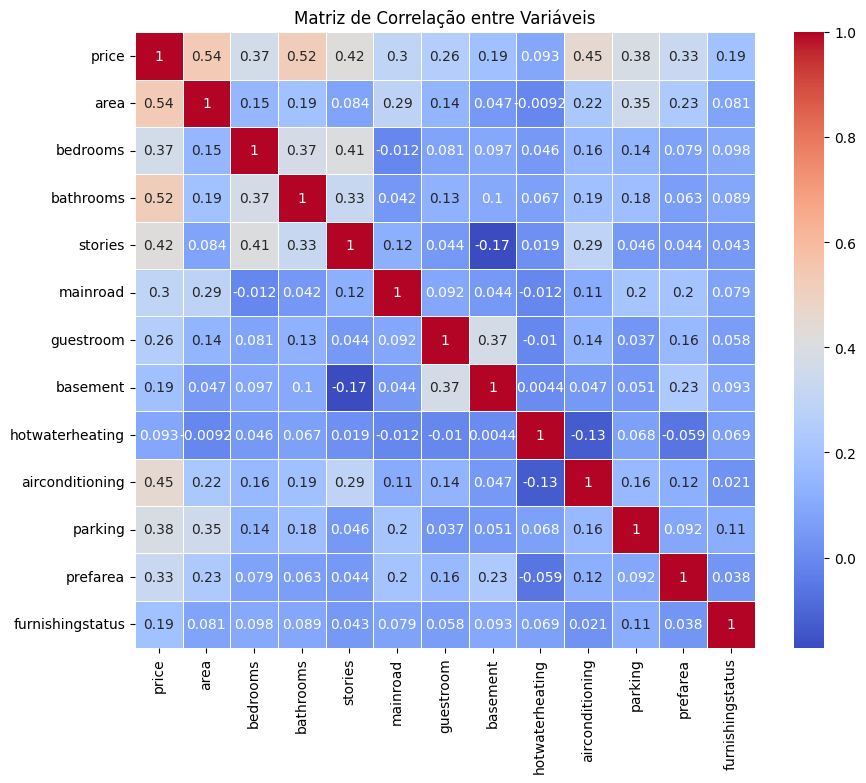

In [ ]:

data = data.replace({'yes':1, 'no':0, 'semi-furnished':2, 'furnished':1, 'unfurnished':0})

features = data.drop(columns=['price'])
target = data['price']

X = features
y = target

# Correlação
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação entre Variáveis')
plt.show()

print(X['furnishingstatus'])

In [ ]:
vif_data = pd.DataFrame()
vif_data['variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

            variable        VIF
0               area   8.274080
1           bedrooms  15.293315
2          bathrooms   9.429678
3            stories   7.886990
4           mainroad   6.871438
5          guestroom   1.468460
6           basement   2.022168
7    hotwaterheating   1.089201
8    airconditioning   1.748656
9            parking   1.959942
10          prefarea   1.486713
11  furnishingstatus   2.727003
0      4
1      4
2      3
3      4
4      4
      ..
540    2
541    3
542    2
543    3
544    3
Name: bedrooms, Length: 545, dtype: int64


In [ ]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(1,)))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='linear'))

opt = tf_keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer='adam', loss='mse')

traning = model.fit(X['bedrooms'], y, epochs=400, validation_split=0.2)

Epoch 1/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 30871648206848.0000 - val_loss: 7582563958784.0000
Epoch 2/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30871635623936.0000 - val_loss: 7582558715904.0000
Epoch 3/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30871618846720.0000 - val_loss: 7582552424448.0000
Epoch 4/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30871604166656.0000 - val_loss: 7582544560128.0000
Epoch 5/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30871585292288.0000 - val_loss: 7582531977216.0000
Epoch 6/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30871549640704.0000 - val_loss: 7582516772864.0000
Epoch 7/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30871509794816.0000 - val_loss: 7582495277056.0000
Epoch 8/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30871457366016.0000 - val_loss: 7582467489792.0000
Epoch 9/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30871381868544.0000 - val_loss: 7582428692480.0000
Epoch 10/

In [23]:
#@title Avaliando multicolinearidade

# Remove variables with (vif > 10)
X_reduced = X.drop(columns='bedrooms')

vif_data_new = pd.DataFrame()
vif_data_new["Variável"] = X_reduced.columns
vif_data_new["VIF"] = [variance_inflation_factor(X_reduced.values, i) for i in range(X_reduced.shape[1])]
print("Fatores de Inflação da Variância sem X2 (VIF):")
print(vif_data_new)

Fatores de Inflação da Variância sem X2 (VIF):
            Variável       VIF
0               area  7.597990
1          bathrooms  7.828199
2            stories  6.256601
3           mainroad  6.679572
4          guestroom  1.459461
5           basement  1.917779
6    hotwaterheating  1.088804
7    airconditioning  1.736419
8            parking  1.959550
9           prefarea  1.483424
10  furnishingstatus  2.708045


Score das variaveis
[218.88408118 198.65452062 116.78040217  52.49183918  37.92827585
 140.16272089  94.14332782  66.25864622  55.58137479]
Melhores variáveis selecionadas pelo SelectKBest: Index(['area', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'airconditioning', 'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


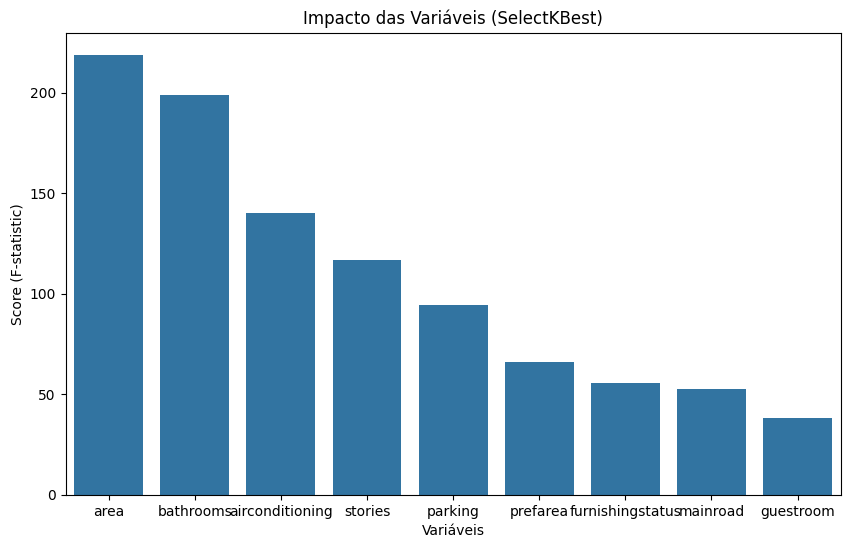

In [54]:
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_reduced, y)
selected_features = selector.get_support(indices=True)
X_selected_features = X_reduced.iloc[:, selected_features]
print("Score das variaveis")
print(selector.scores_)
print("Melhores variáveis selecionadas pelo SelectKBest:", X_selected_features.columns)



scores = selector.scores_
kbest_df = pd.DataFrame({'Features': X_reduced.columns, 'Score':scores})
kbest_df = kbest_df.sort_values(by='Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Features', y='Score', data=kbest_df)
plt.xlabel('Variáveis')
plt.ylabel('Score (F-statistic)')
plt.title('Impacto das Variáveis (SelectKBest)')
plt.show()

In [ ]:
X_reduced = X_reduced.drop(columns=['basement', 'hotwaterheating'])

In [56]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(X_reduced.shape[1],)))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mse')

traning = model.fit(X_reduced, y, epochs=400, validation_split=0.2)

Epoch 1/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 30864236871680.0000 - val_loss: 7576248385536.0000
Epoch 2/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30829107478528.0000 - val_loss: 7552209780736.0000
Epoch 3/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30687700713472.0000 - val_loss: 7457881456640.0000
Epoch 4/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30168401838080.0000 - val_loss: 7124004896768.0000
Epoch 5/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 28429944619008.0000 - val_loss: 6135529603072.0000
Epoch 6/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 23732112326656.0000 - val_loss: 3852433358848.0000
Epoch 7/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14178069774336.0000 - val_loss: 976652861440.0000
Epoch 8/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4926340595712.0000 - val_loss: 2818761555968.0000
Epoch 9/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4191965413376.0000 - val_loss: 1815747493888.0000
Epoch 10/400

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


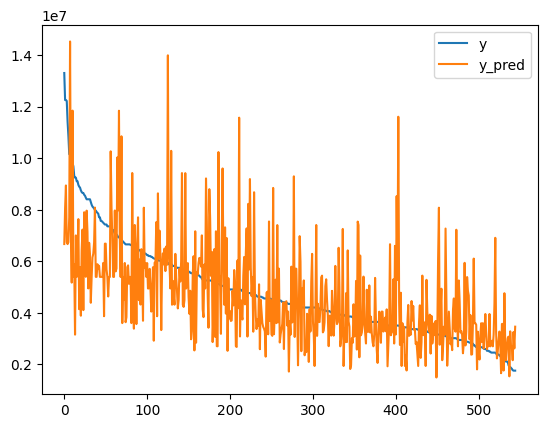

In [20]:
y_pred = model.predict(X_reduced)
plt.plot(y, label='y')
plt.plot(y_pred, label='y_pred')
plt.legend()
plt.show()